# LungAI-CDSS

## Explainable Artificial Intelligence-Based Clinical Decision Support System for CT-Based Lung Nodule Malignancy Risk Prediction

### MSc Dissertation Demonstration Notebook

**Author:** Samuel Idowu  
**Programme:** MSc Health Analytics and Technologies  
**Institution:** University of Greater Manchester  
**Year:** 2026

---

## Purpose of the Notebook

This notebook demonstrates the machine learning workflow used to develop the LungAI-CDSS prototype.

The workflow includes:

- Loading the processed LIDC-IDRI feature dataset
- Inspecting the dataset
- Preparing predictors and target labels
- Splitting the dataset into training and testing subsets
- Training Logistic Regression, Random Forest, LightGBM and XGBoost
- Comparing model performance
- Selecting the final model
- Generating SHAP explanations
- Generating LIME explanations
- Saving the trained model and preprocessing assets

Import Libraries to use for analysis


In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap
from lime.lime_tabular import LimeTabularExplainer

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the Processed Dataset

The processed dataset contains one record per clustered lung nodule. Each record includes radiologist-derived semantic imaging characteristics and a binary target representing either low risk or suspicious risk.

In [8]:
# Load dataset

from pathlib import Path
import pandas as pd

PROJECT_DIR = Path.cwd()

DATA_PATH = PROJECT_DIR / "lidc_model_dataset_binary.csv"

print("Project directory:")
print(PROJECT_DIR)

print("\nDataset path:")
print(DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Project directory:
C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS

Dataset path:
C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\lidc_model_dataset_binary.csv

Dataset loaded successfully!
Dataset shape: (2651, 22)


,patient_id,nodule_number,number_of_radiologists,mean_malignancy_score,subtlety,subtlety_std,internalStructure,internalStructure_std,calcification,calcification_std,...,margin,margin_std,lobulation,lobulation_std,spiculation,spiculation_std,texture,texture_std,target,risk_group
0,LIDC-IDRI-0078,1,4,3.75,4.50,0.500000,1.0,0.0,6.0,0.0,...,3.25,0.829156,2.25,1.089725,2.25,1.089725,4.75,0.433013,1,Suspicious risk
1,LIDC-IDRI-0078,2,4,3.75,4.75,0.433013,1.0,0.0,6.0,0.0,...,2.75,0.829156,3.00,1.224745,2.25,1.299038,4.50,0.500000,1,Suspicious risk
2,LIDC-IDRI-0078,3,1,1.00,4.00,0.000000,1.0,0.0,5.0,0.0,...,5.00,0.000000,1.00,0.000000,1.00,0.000000,5.00,0.000000,0,Low risk
3,LIDC-IDRI-0078,4,4,4.25,5.00,0.000000,1.0,0.0,5.0,1.0,...,3.25,1.299038,3.25,0.829156,2.75,1.089725,4.75,0.433013,1,Suspicious risk
4,LIDC-IDRI-0069,1,4,3.25,2.50,0.500000,1.0,0.0,6.0,0.0,...,4.25,0.829156,4.00,1.224745,4.00,1.732051,4.75,0.433013,1,Suspicious risk


## 2. Exploratory Data Analysis (EDA)

Before developing the machine learning models, the processed dataset is explored to understand its structure, variable types, class distribution and missing values. This step verifies the integrity of the dataset and ensures that the selected radiological features are suitable for predictive modelling.

In [9]:
# Display the first five observations

df.head()

,patient_id,nodule_number,number_of_radiologists,mean_malignancy_score,subtlety,subtlety_std,internalStructure,internalStructure_std,calcification,calcification_std,...,margin,margin_std,lobulation,lobulation_std,spiculation,spiculation_std,texture,texture_std,target,risk_group
0,LIDC-IDRI-0078,1,4,3.75,4.50,0.500000,1.0,0.0,6.0,0.0,...,3.25,0.829156,2.25,1.089725,2.25,1.089725,4.75,0.433013,1,Suspicious risk
1,LIDC-IDRI-0078,2,4,3.75,4.75,0.433013,1.0,0.0,6.0,0.0,...,2.75,0.829156,3.00,1.224745,2.25,1.299038,4.50,0.500000,1,Suspicious risk
2,LIDC-IDRI-0078,3,1,1.00,4.00,0.000000,1.0,0.0,5.0,0.0,...,5.00,0.000000,1.00,0.000000,1.00,0.000000,5.00,0.000000,0,Low risk
3,LIDC-IDRI-0078,4,4,4.25,5.00,0.000000,1.0,0.0,5.0,1.0,...,3.25,1.299038,3.25,0.829156,2.75,1.089725,4.75,0.433013,1,Suspicious risk
4,LIDC-IDRI-0069,1,4,3.25,2.50,0.500000,1.0,0.0,6.0,0.0,...,4.25,0.829156,4.00,1.224745,4.00,1.732051,4.75,0.433013,1,Suspicious risk


In [10]:
# Display dataset dimensions

print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

Number of observations: 2651
Number of variables: 22


In [11]:
# Display column names

print(df.columns.tolist())

['patient_id', 'nodule_number', 'number_of_radiologists', 'mean_malignancy_score', 'subtlety', 'subtlety_std', 'internalStructure', 'internalStructure_std', 'calcification', 'calcification_std', 'sphericity', 'sphericity_std', 'margin', 'margin_std', 'lobulation', 'lobulation_std', 'spiculation', 'spiculation_std', 'texture', 'texture_std', 'target', 'risk_group']


In [12]:
# Display data types

df.dtypes

patient_id                    str
nodule_number               int64
number_of_radiologists      int64
mean_malignancy_score     float64
subtlety                  float64
subtlety_std              float64
internalStructure         float64
internalStructure_std     float64
calcification             float64
calcification_std         float64
sphericity                float64
sphericity_std            float64
margin                    float64
margin_std                float64
lobulation                float64
lobulation_std            float64
spiculation               float64
spiculation_std           float64
texture                   float64
texture_std               float64
target                      int64
risk_group                    str
dtype: object

In [13]:
# Summary statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
nodule_number,2651.0,3.158431,2.779538,1.0,1.00,2.000000,4.000000,23.000000
number_of_radiologists,2651.0,2.587326,1.249986,1.0,1.00,3.000000,4.000000,8.000000
mean_malignancy_score,2651.0,2.695346,0.919823,1.0,2.00,2.750000,3.000000,5.000000
subtlety,2651.0,3.661871,1.076429,1.0,3.00,4.000000,4.500000,5.000000
subtlety_std,2651.0,0.430081,0.445741,0.0,0.00,0.433013,0.816497,2.000000
internalStructure,2651.0,1.014347,0.159966,1.0,1.00,1.000000,1.000000,5.000000
internalStructure_std,2651.0,0.011212,0.118815,0.0,0.00,0.000000,0.000000,1.500000
calcification,2651.0,5.672620,0.856693,2.5,6.00,6.000000,6.000000,6.000000
calcification_std,2651.0,0.094771,0.335537,0.0,0.00,0.000000,0.000000,2.165064
sphericity,2651.0,3.773685,0.780759,1.0,3.00,4.000000,4.333333,5.000000


In [14]:
# Check missing values

missing = df.isnull().sum()

missing

patient_id                0
nodule_number             0
number_of_radiologists    0
mean_malignancy_score     0
subtlety                  0
subtlety_std              0
internalStructure         0
internalStructure_std     0
calcification             0
calcification_std         0
sphericity                0
sphericity_std            0
margin                    0
margin_std                0
lobulation                0
lobulation_std            0
spiculation               0
spiculation_std           0
texture                   0
texture_std               0
target                    0
risk_group                0
dtype: int64

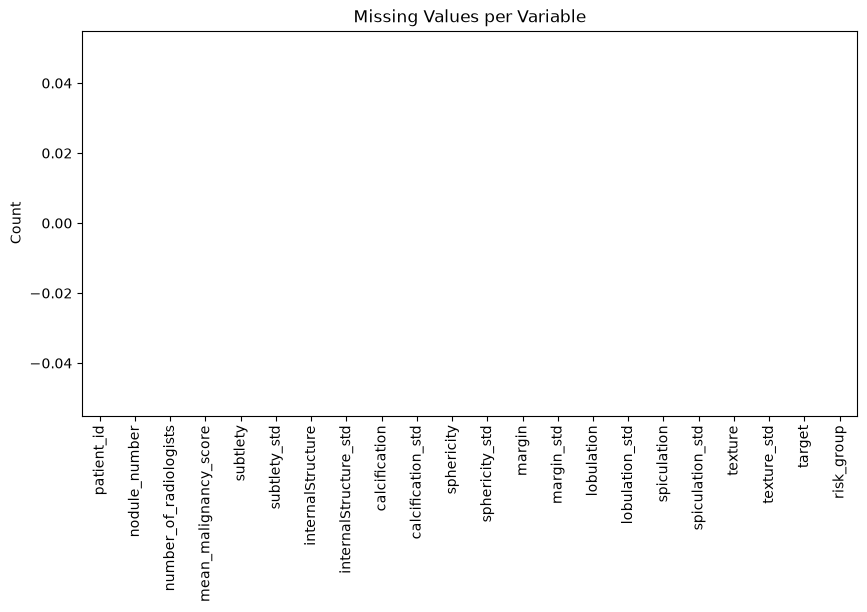

In [15]:
# Visualise missing values

import matplotlib.pyplot as plt

missing = df.isnull().sum()

plt.figure(figsize=(10,5))

missing.plot(kind="bar")

plt.title("Missing Values per Variable")

plt.ylabel("Count")

plt.show()

The chart shows nothing because there is no missing value out of the variables in the dataset.

In [16]:
# Display target distribution

df["risk_group"].value_counts()

risk_group
Suspicious risk    1867
Low risk            784
Name: count, dtype: int64

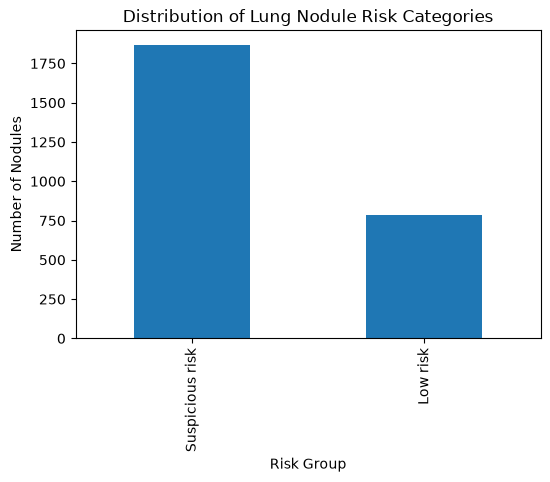

In [17]:
# Plot target distribution

import matplotlib.pyplot as plt

df["risk_group"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Distribution of Lung Nodule Risk Categories")

plt.xlabel("Risk Group")

plt.ylabel("Number of Nodules")

plt.show()

### Exploratory Data Analysis Summary

The exploratory analysis confirmed that the processed dataset was successfully loaded and contained the radiologist-derived imaging features required for predictive modelling. Dataset dimensions, variable types and summary statistics were examined, while missing values and class distribution were assessed to ensure data quality prior to model development.

---

## 3. Data Preprocessing

The modelling dataset contains patient identifiers, nodule identifiers, the mean malignancy score and target labels. These columns are excluded from the predictor matrix because they are not intended as model inputs. In particular, the mean malignancy score is excluded because the binary target was derived from it; retaining it would introduce target leakage.

Missing predictor values are handled within each machine learning pipeline using median imputation.


In [18]:
exclude_columns = [
    "patient_id",
    "nodule_number",
    "mean_malignancy_score",
    "target",
    "risk_group",
]

print("Columns excluded from modelling:")

for column in exclude_columns:
    print("-", column)

Columns excluded from modelling:
- patient_id
- nodule_number
- mean_malignancy_score
- target
- risk_group


In [20]:
# To Confirm that all required columns are present we will use these code

missing_columns = [
    column
    for column in exclude_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}"
    )

# Predictor matrix
X = df.drop(columns=exclude_columns).copy()

# Binary target
y = df["target"].astype(int).copy()

print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeatures used for modelling:")

for feature in X.columns:
    print("-", feature)

Predictor matrix shape: (2651, 17)
Target vector shape: (2651,)

Features used for modelling:
- number_of_radiologists
- subtlety
- subtlety_std
- internalStructure
- internalStructure_std
- calcification
- calcification_std
- sphericity
- sphericity_std
- margin
- margin_std
- lobulation
- lobulation_std
- spiculation
- spiculation_std
- texture
- texture_std


In [21]:
# Check that all model predictors are numeric

non_numeric_columns = (
    X.select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

if non_numeric_columns:
    raise TypeError(
        "The following predictor columns are not numeric: "
        f"{non_numeric_columns}"
    )

print("All predictor columns are numeric.")

All predictor columns are numeric.


In [22]:
print("Unique target values:", sorted(y.unique()))

print("\nTarget distribution:")
print(y.value_counts().sort_index())

if not set(y.unique()).issubset({0, 1}):
    raise ValueError(
        "The target must contain only binary values 0 and 1."
    )

print("\nTarget validation completed successfully.")

Unique target values: [np.int64(0), np.int64(1)]

Target distribution:
target
0     784
1    1867
Name: count, dtype: int64

Target validation completed successfully.


## 4. Training and Testing Split

The processed dataset is divided into training and testing subsets using an 80:20 ratio. Stratified sampling preserves the proportion of low-risk and suspicious-risk nodules in both subsets. A fixed random state of 42 is used to support reproducibility.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training predictor shape:", X_train.shape)
print("Testing predictor shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

Training predictor shape: (2120, 17)
Testing predictor shape: (531, 17)

Training target distribution:
target
0     627
1    1493
Name: count, dtype: int64

Testing target distribution:
target
0    157
1    374
Name: count, dtype: int64


In [24]:
class_proportions = pd.DataFrame(
    {
        "Full dataset": y.value_counts(normalize=True).sort_index(),
        "Training set": y_train.value_counts(normalize=True).sort_index(),
        "Testing set": y_test.value_counts(normalize=True).sort_index(),
    }
)

class_proportions.index = [
    "Low Risk",
    "Suspicious Risk",
]

display(
    class_proportions.round(4)
)

,Full dataset,Training set,Testing set
Low Risk,0.2957,0.2958,0.2957
Suspicious Risk,0.7043,0.7042,0.7043


### Preprocessing Summary

The modelling dataset was separated into predictor and target variables after removing identifiers and target-related columns. All remaining predictor variables were numeric. The dataset was then divided into stratified training and testing subsets, preserving the class distribution for reliable model comparison.

## 5. Machine Learning Model Development

Four supervised machine learning algorithms are trained and compared using the same training and testing data:

- Logistic Regression
- Random Forest
- XGBoost
- LightGBM

Each model is implemented within a pipeline. Median imputation is applied to missing values, while StandardScaler is additionally applied to Logistic Regression because it is sensitive to feature scale.

In [26]:
models = {
    "Logistic Regression": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
            ),
        ),
    ]),

    "Random Forest": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
            ),
        ),
    ]),

    "XGBoost": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                random_state=42,
                eval_metric="logloss",
            ),
        ),
    ]),

    "LightGBM": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "model",
            LGBMClassifier(
                n_estimators=300,
                learning_rate=0.05,
                random_state=42,
                class_weight="balanced",
                verbosity=-1,
            ),
        ),
    ]),
}

print("Model pipelines created successfully.")

for model_name in models:
    print("-", model_name)

Model pipelines created successfully.
- Logistic Regression
- Random Forest
- XGBoost
- LightGBM


## 6. Model Training and Evaluation

Each model is trained on the training subset and evaluated using the independent testing subset. Performance is assessed using accuracy, precision, recall or sensitivity, specificity, F1-score and ROC-AUC. The confusion-matrix counts are also retained for comparison.

In [27]:
results = []
trained_models = {}

for model_name, model in models.items():
    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    # Train the model
    model.fit(X_train, y_train)

    trained_models[model_name] = model

    # Generate predictions and probabilities
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1],
    ).ravel()

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0,
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0,
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0,
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob,
    )

    # Store results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall/Sensitivity": recall,
        "Specificity": specificity,
        "F1-score": f1,
        "ROC-AUC": roc_auc,
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp,
    })

    # Print individual model results
    print("Confusion Matrix:")
    print(
        np.array([
            [tn, fp],
            [fn, tp],
        ])
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Low Risk",
                "Suspicious Risk",
            ],
            digits=4,
        )
    )

    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall/Sensitivity:", round(recall, 4))
    print("Specificity:", round(specificity, 4))
    print("F1-score:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc, 4))

print("\nAll models trained and evaluated successfully.")


Logistic Regression
Confusion Matrix:
[[126  31]
 [ 74 300]]

Classification Report:
                 precision    recall  f1-score   support

       Low Risk     0.6300    0.8025    0.7059       157
Suspicious Risk     0.9063    0.8021    0.8511       374

       accuracy                         0.8023       531
      macro avg     0.7682    0.8023    0.7785       531
   weighted avg     0.8246    0.8023    0.8081       531

Accuracy: 0.8023
Precision: 0.9063
Recall/Sensitivity: 0.8021
Specificity: 0.8025
F1-score: 0.8511
ROC-AUC: 0.8933

Random Forest
Confusion Matrix:
[[121  36]
 [ 55 319]]

Classification Report:
                 precision    recall  f1-score   support

       Low Risk     0.6875    0.7707    0.7267       157
Suspicious Risk     0.8986    0.8529    0.8752       374

       accuracy                         0.8286       531
      macro avg     0.7930    0.8118    0.8009       531
   weighted avg     0.8362    0.8286    0.8313       531

Accuracy: 0.8286
Precision: 0

In [28]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False,
).reset_index(drop=True)

display(
    results_df.round(6)
)

,Model,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-score,ROC-AUC,True Negative,False Positive,False Negative,True Positive
0,XGBoost,0.849341,0.875000,0.917112,0.687898,0.895561,0.907805,108,49,31,343
1,LightGBM,0.826742,0.896067,0.852941,0.764331,0.873973,0.904961,120,37,55,319
2,Logistic Regression,0.802260,0.906344,0.802139,0.802548,0.851064,0.893329,126,31,74,300
3,Random Forest,0.828625,0.898592,0.852941,0.770701,0.875171,0.893125,121,36,55,319


In [29]:
principal_metrics = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall/Sensitivity",
    "Specificity",
    "F1-score",
    "ROC-AUC",
]

display(
    results_df[principal_metrics].round(4)
)

,Model,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-score,ROC-AUC
0,XGBoost,0.8493,0.8750,0.9171,0.6879,0.8956,0.9078
1,LightGBM,0.8267,0.8961,0.8529,0.7643,0.8740,0.9050
2,Logistic Regression,0.8023,0.9063,0.8021,0.8025,0.8511,0.8933
3,Random Forest,0.8286,0.8986,0.8529,0.7707,0.8752,0.8931


In [30]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

best_model_results = results_df.iloc[[0]]

print(
    "Best model selected by ROC-AUC:",
    best_model_name,
)

display(
    best_model_results.round(6)
)

Best model selected by ROC-AUC: XGBoost


,Model,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-score,ROC-AUC,True Negative,False Positive,False Negative,True Positive
0,XGBoost,0.849341,0.875,0.917112,0.687898,0.895561,0.907805,108,49,31,343


### Model-Selection Summary

The models were ranked primarily using ROC-AUC because this metric evaluates class discrimination across different classification thresholds. Accuracy, sensitivity, specificity, precision and F1-score were considered alongside ROC-AUC to ensure that the selected model achieved balanced predictive performance.

The highest-performing model is retained for subsequent explainability analysis and model export.

In [31]:
csv_results_path = (
    PROJECT_DIR
    / "model_performance_results_notebook.csv"
)

excel_results_path = (
    PROJECT_DIR
    / "model_performance_results_notebook.xlsx"
)

results_df.to_csv(
    csv_results_path,
    index=False,
)

results_df.to_excel(
    excel_results_path,
    index=False,
)

print("Results saved successfully:")
print("-", csv_results_path)
print("-", excel_results_path)

Results saved successfully:
- C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\model_performance_results_notebook.csv
- C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\model_performance_results_notebook.xlsx


## 7. Model Performance Visualisation

The comparative performance of the four machine learning models is visualised using grouped performance charts, ROC curves and a confusion matrix for the selected model.

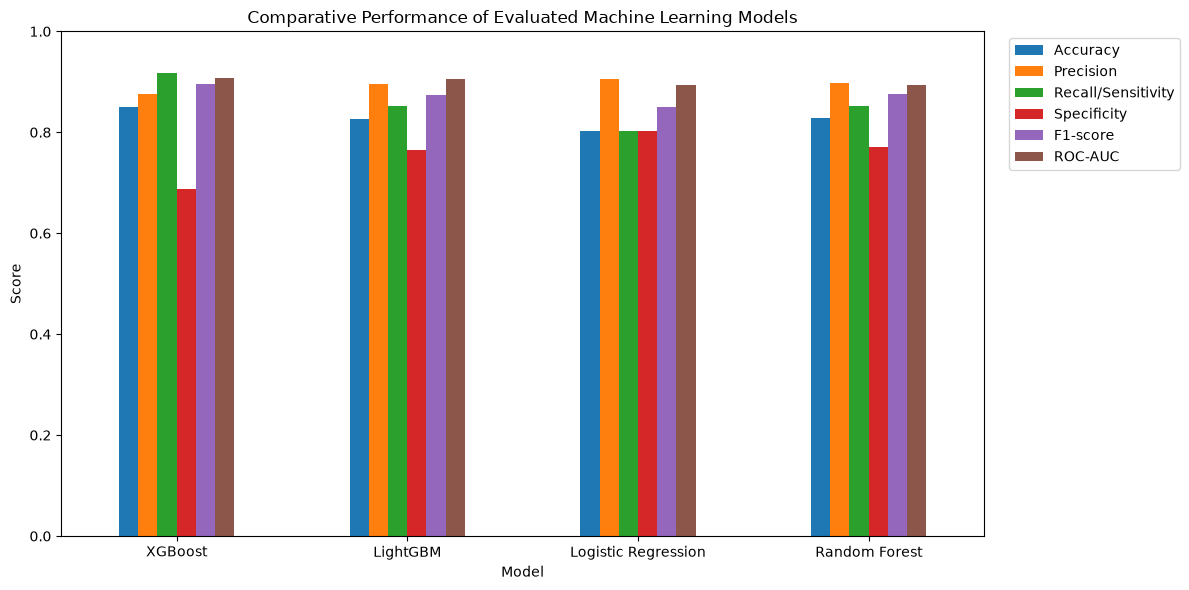

Saved to:
C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\model_performance_comparison_notebook.png


In [32]:
comparison_metrics = [
    "Accuracy",
    "Precision",
    "Recall/Sensitivity",
    "Specificity",
    "F1-score",
    "ROC-AUC",
]

comparison_df = results_df.set_index(
    "Model"
)[comparison_metrics]

ax = comparison_df.plot(
    kind="bar",
    figsize=(12, 6),
)

ax.set_title(
    "Comparative Performance of Evaluated Machine Learning Models"
)

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()

comparison_chart_path = (
    PROJECT_DIR
    / "model_performance_comparison_notebook.png"
)

plt.savefig(
    comparison_chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:")
print(comparison_chart_path)

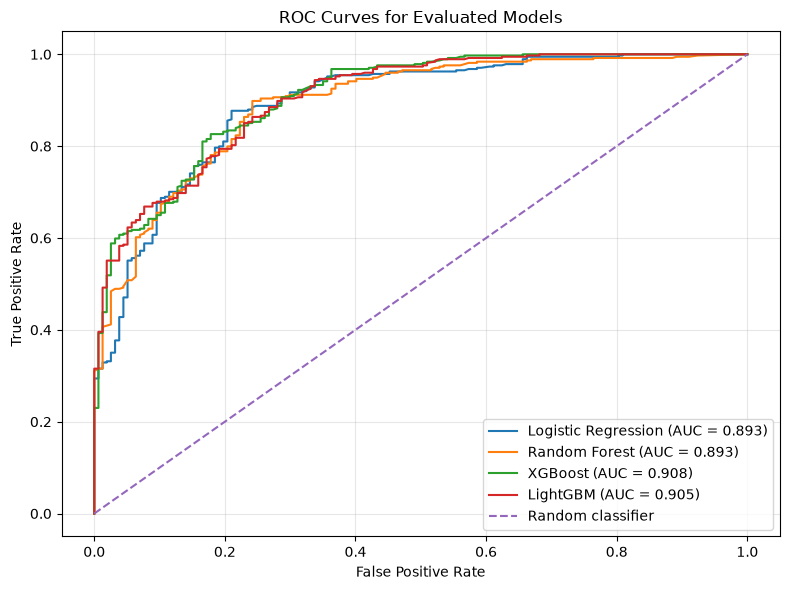

Saved to:
C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\model_roc_curves_notebook.png


In [33]:
plt.figure(figsize=(8, 6))

for model_name, model in trained_models.items():
    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probabilities,
    )

    model_auc = auc(
        false_positive_rate,
        true_positive_rate,
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC = {model_auc:.3f})",
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Evaluated Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

roc_curve_path = (
    PROJECT_DIR
    / "model_roc_curves_notebook.png"
)

plt.savefig(
    roc_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:")
print(roc_curve_path)

In [34]:
best_predictions = best_model.predict(
    X_test
)

best_probabilities = best_model.predict_proba(
    X_test
)[:, 1]

print("Selected model:", best_model_name)

Selected model: XGBoost


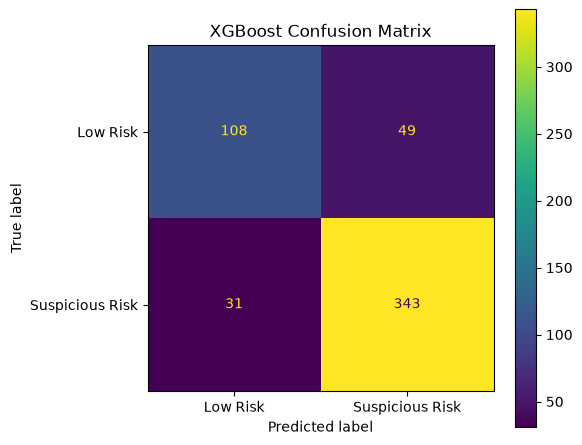

Saved to:
C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\selected_model_confusion_matrix_notebook.png


In [35]:
figure, axis = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    display_labels=[
        "Low Risk",
        "Suspicious Risk",
    ],
    values_format="d",
    ax=axis,
)

axis.set_title(
    f"{best_model_name} Confusion Matrix"
)

plt.tight_layout()

confusion_matrix_path = (
    PROJECT_DIR
    / "selected_model_confusion_matrix_notebook.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:")
print(confusion_matrix_path)

In [36]:
# Detailed report for the selected model

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "Low Risk",
            "Suspicious Risk",
        ],
        digits=4,
    )
)

                 precision    recall  f1-score   support

       Low Risk     0.7770    0.6879    0.7297       157
Suspicious Risk     0.8750    0.9171    0.8956       374

       accuracy                         0.8493       531
      macro avg     0.8260    0.8025    0.8126       531
   weighted avg     0.8460    0.8493    0.8465       531



### Performance Interpretation

The visual evaluation compares overall classification performance across the four models. ROC curves illustrate the ability of each model to distinguish between low-risk and suspicious-risk nodules across different thresholds. The confusion matrix provides the true-negative, false-positive, false-negative and true-positive counts for the selected model.

## 8. SHAP Explainability

SHAP is used to explain the selected tree-based model at both global and patient-specific levels. Because SHAP's TreeExplainer operates on the fitted estimator rather than the full scikit-learn pipeline, the fitted imputer and classifier are extracted from the selected pipeline.

In [37]:
xgb_pipeline = trained_models["XGBoost"]

xgb_imputer = xgb_pipeline.named_steps[
    "imputer"
]

xgb_model = xgb_pipeline.named_steps[
    "model"
]

X_train_imputed = xgb_imputer.transform(
    X_train
)

X_test_imputed = xgb_imputer.transform(
    X_test
)

X_train_imputed_df = pd.DataFrame(
    X_train_imputed,
    columns=X.columns,
    index=X_train.index,
)

X_test_imputed_df = pd.DataFrame(
    X_test_imputed,
    columns=X.columns,
    index=X_test.index,
)

print("XGBoost model and imputed data prepared for SHAP.")

XGBoost model and imputed data prepared for SHAP.


In [38]:
# To Create SHAP explainer and values
shap_explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = shap_explainer.shap_values(
    X_test_imputed_df
)

print(
    "SHAP values generated successfully."
)

SHAP values generated successfully.


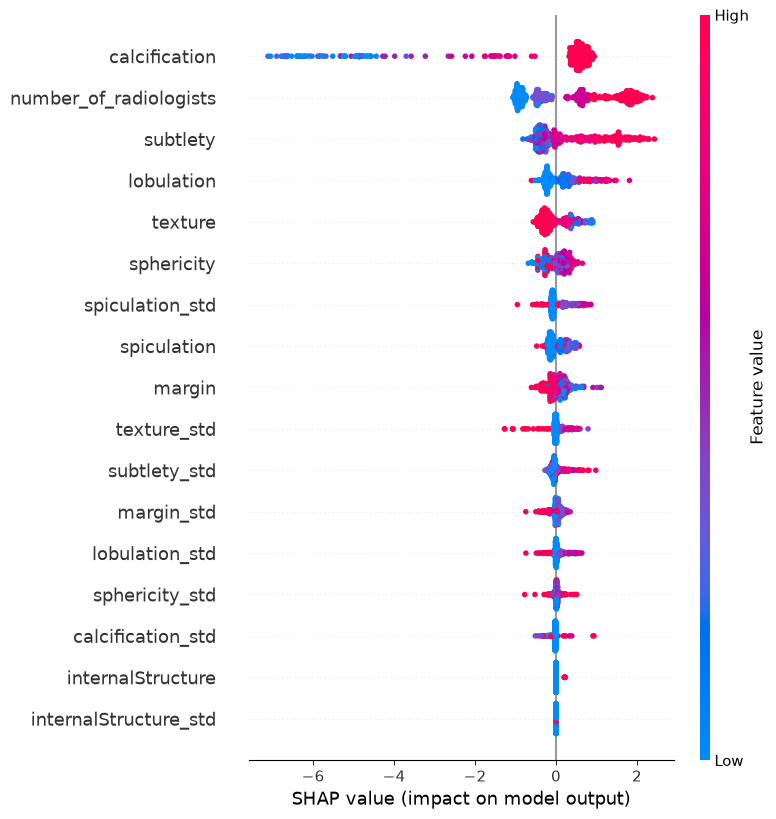

Saved to:
C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\shap_summary_plot_notebook.png


In [39]:
# For Global SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test_imputed_df,
    show=False,
)

plt.tight_layout()

shap_summary_path = (
    PROJECT_DIR
    / "shap_summary_plot_notebook.png"
)

plt.savefig(
    shap_summary_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:")
print(shap_summary_path)

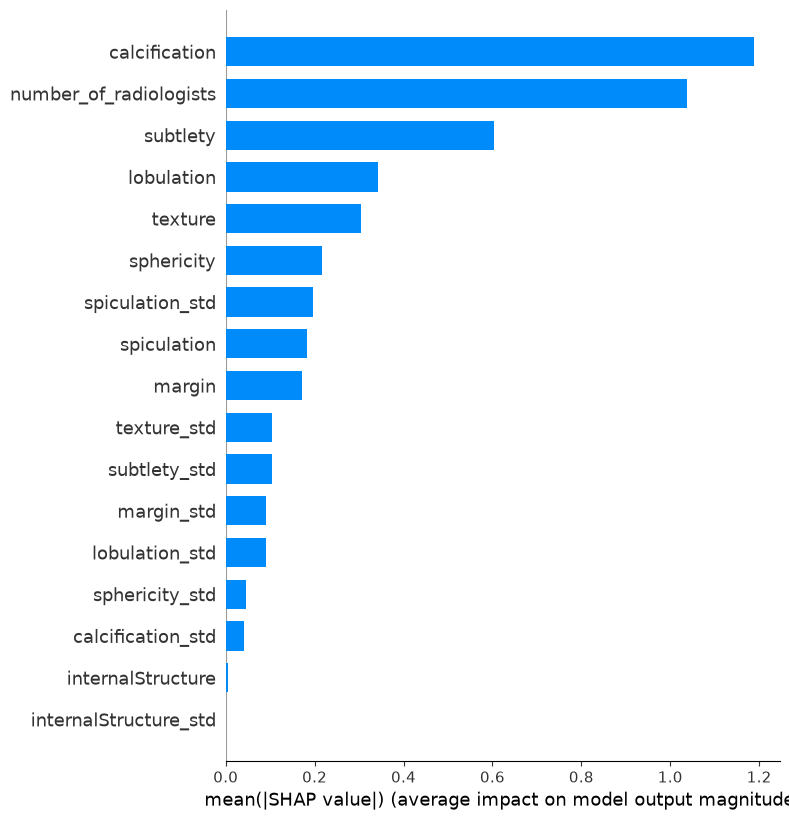

Saved to:
C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\shap_feature_importance_bar_notebook.png


In [40]:
# I also need the Global SHAP importance bar chart 
shap.summary_plot(
    shap_values,
    X_test_imputed_df,
    plot_type="bar",
    show=False,
)

plt.tight_layout()

shap_bar_path = (
    PROJECT_DIR
    / "shap_feature_importance_bar_notebook.png"
)

plt.savefig(
    shap_bar_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:")
print(shap_bar_path)

## 9. Patient-Specific SHAP Explanation

A patient-specific SHAP waterfall plot is generated for LIDC-IDRI-0001, nodule 1. This case is used to demonstrate how individual radiological features increase or reduce the model output for a single prediction.

In [42]:
# Now i need to select a specific Patient ID to carry out SHAP explanation
selected_patient_id = "LIDC-IDRI-0001"
selected_nodule_number = 1

selected_rows = df[
    (df["patient_id"].astype(str) == selected_patient_id)
    & (
        df["nodule_number"].astype(int)
        == selected_nodule_number
    )
].copy()

if selected_rows.empty:
    raise ValueError(
        f"No record was found for {selected_patient_id}, "
        f"nodule {selected_nodule_number}."
    )

selected_row = selected_rows.iloc[0]

print("Selected patient:", selected_patient_id)
print("Selected nodule:", selected_nodule_number)
print("Recorded risk group:", selected_row["risk_group"])
print("Target value:", int(selected_row["target"]))

Selected patient: LIDC-IDRI-0001
Selected nodule: 1
Recorded risk group: Suspicious risk
Target value: 1


In [43]:
# now this script below would be used to treat the selected case (Patient ID) 
selected_case = pd.DataFrame(
    [selected_row[X.columns].to_dict()],
    columns=X.columns,
)

selected_case_imputed = xgb_imputer.transform(
    selected_case
)

selected_case_imputed_df = pd.DataFrame(
    selected_case_imputed,
    columns=X.columns,
)

selected_prediction = int(
    xgb_model.predict(
        selected_case_imputed
    )[0]
)

selected_probabilities = xgb_model.predict_proba(
    selected_case_imputed
)[0]

selected_label = (
    "Suspicious Risk"
    if selected_prediction == 1
    else "Low Risk"
)

print("Predicted class:", selected_label)
print(
    "Low-risk probability:",
    round(float(selected_probabilities[0]), 4),
)
print(
    "Suspicious-risk probability:",
    round(float(selected_probabilities[1]), 4),
)

Predicted class: Suspicious Risk
Low-risk probability: 0.001
Suspicious-risk probability: 0.999


In [44]:
# Is now turn to Generate SHAP values for the selected case
selected_shap_values = shap_explainer.shap_values(
    selected_case_imputed_df
)

print("Patient-specific SHAP values generated.")

Patient-specific SHAP values generated.


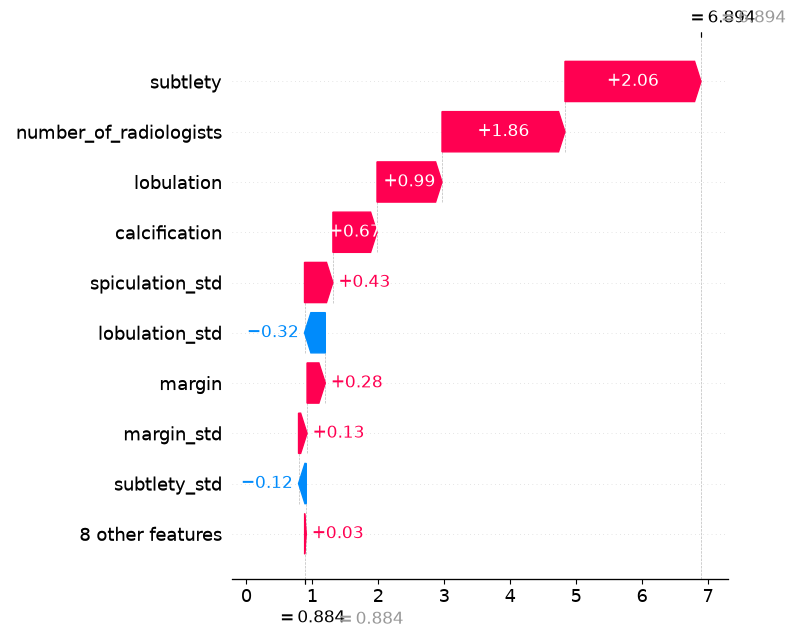

Saved to:
C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\shap_waterfall_LIDC_IDRI_0001_notebook.png


In [45]:
# To have SHAP waterfall plot, i need to use the script 
plt.figure(figsize=(10, 6))

shap.plots._waterfall.waterfall_legacy(
    shap_explainer.expected_value,
    selected_shap_values[0],
    selected_case_imputed_df.iloc[0],
    show=False,
)

plt.tight_layout()

shap_waterfall_path = (
    PROJECT_DIR
    / "shap_waterfall_LIDC_IDRI_0001_notebook.png"
)

plt.savefig(
    shap_waterfall_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved to:")
print(shap_waterfall_path)

In [46]:
# To Display the strongest SHAP contributions
shap_contributions = pd.DataFrame(
    {
        "Feature": X.columns,
        "Feature Value": selected_case_imputed_df.iloc[0].values,
        "SHAP Value": selected_shap_values[0],
    }
)

shap_contributions["Absolute SHAP Value"] = (
    shap_contributions["SHAP Value"].abs()
)

shap_contributions = shap_contributions.sort_values(
    by="Absolute SHAP Value",
    ascending=False,
).reset_index(drop=True)

display(
    shap_contributions.head(10).round(4)
)

,Feature,Feature Value,SHAP Value,Absolute SHAP Value
0,subtlety,5.0000,2.0624,2.0624
1,number_of_radiologists,4.0000,1.8644,1.8644
2,lobulation,3.0000,0.9857,0.9857
3,calcification,6.0000,0.6689,0.6689
4,spiculation_std,0.8292,0.4306,0.4306
5,lobulation_std,1.4142,-0.3156,0.3156
6,margin,3.2500,0.2769,0.2769
7,margin_std,0.8292,0.1292,0.1292
8,subtlety_std,0.0000,-0.1175,0.1175
9,texture_std,0.4330,0.1167,0.1167


## 10. LIME Explainability

LIME provides an additional local explanation for the same patient and nodule. It approximates the XGBoost model within the neighbourhood of the selected observation and identifies the features that most strongly support either the low-risk or suspicious-risk prediction.

In [48]:
# For futher explanation, i use the LIME to have an indepth explanation
lime_explainer = LimeTabularExplainer(
    training_data=np.asarray(
        X_train_imputed_df
    ),
    feature_names=list(X.columns),
    class_names=[
        "Low Risk",
        "Suspicious Risk",
    ],
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

print("LIME explainer created successfully.")

LIME explainer created successfully.


In [49]:
lime_explanation = lime_explainer.explain_instance(
    data_row=selected_case_imputed[0],
    predict_fn=xgb_model.predict_proba,
    num_features=min(
        10,
        len(X.columns),
    ),
    num_samples=5000,
)

print("Top LIME feature contributions:\n")

for feature, weight in lime_explanation.as_list():
    print(
        f"{feature}: {weight:+.4f}"
    )

Top LIME feature contributions:

3.00 < number_of_radiologists <= 4.00: +0.2234
subtlety > 4.50: +0.1956
margin <= 3.25: +0.1423
lobulation > 2.00: +0.1338
internalStructure <= 1.00: -0.1054
4.00 < texture <= 5.00: -0.0822
subtlety_std <= 0.00: -0.0351
calcification_std <= 0.00: -0.0285
spiculation_std > 0.50: +0.0281
sphericity_std > 0.71: +0.0237


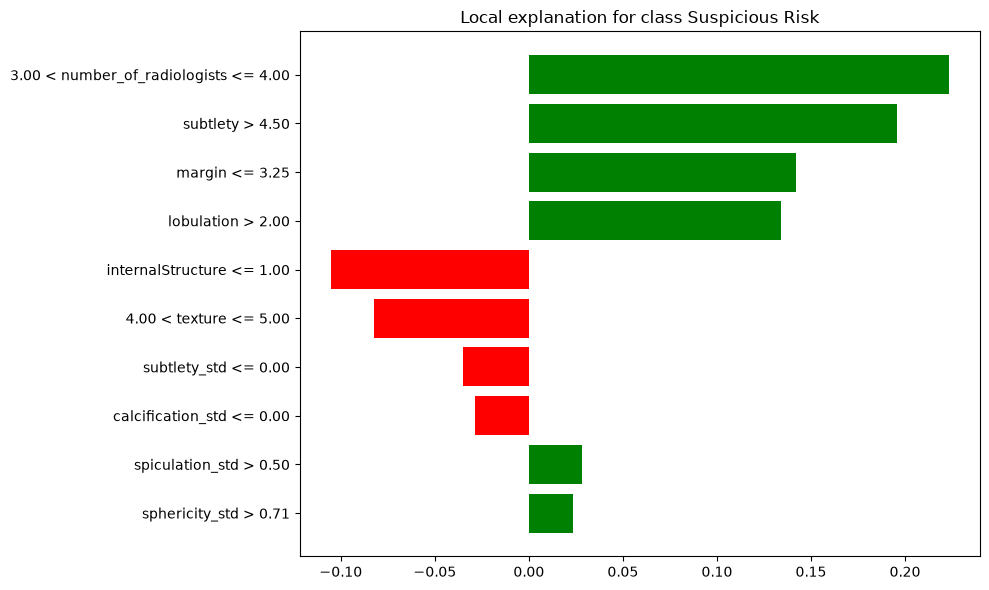

Saved to:
C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\lime_explanation_LIDC_IDRI_0001_notebook.png


In [50]:
# To Generate LIME CHart 
lime_figure = lime_explanation.as_pyplot_figure()

lime_figure.set_size_inches(
    10,
    6,
)

plt.tight_layout()

lime_plot_path = (
    PROJECT_DIR
    / "lime_explanation_LIDC_IDRI_0001_notebook.png"
)

plt.savefig(
    lime_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:")
print(lime_plot_path)

In [51]:
# I need to generate an html directory 
lime_html_path = (
    PROJECT_DIR
    / "lime_LIDC_IDRI_0001_nodule_1_notebook.html"
)

lime_explanation.save_to_file(
    str(lime_html_path)
)

print("Interactive LIME explanation saved to:")
print(lime_html_path)

Interactive LIME explanation saved to:
C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\lime_LIDC_IDRI_0001_nodule_1_notebook.html


# To Compare LIME and SHAP Contribution

In [52]:
lime_contributions = pd.DataFrame(
    lime_explanation.as_list(),
    columns=[
        "LIME Feature Condition",
        "LIME Weight",
    ],
)

display(
    lime_contributions.round(4)
)

,LIME Feature Condition,LIME Weight
0,3.00 < number_of_radiologists <= 4.00,0.2234
1,subtlety > 4.50,0.1956
2,margin <= 3.25,0.1423
3,lobulation > 2.00,0.1338
4,internalStructure <= 1.00,-0.1054
5,4.00 < texture <= 5.00,-0.0822
6,subtlety_std <= 0.00,-0.0351
7,calcification_std <= 0.00,-0.0285
8,spiculation_std > 0.50,0.0281
9,sphericity_std > 0.71,0.0237


### Local Explainability Interpretation

The SHAP and LIME explanations provide complementary views of the selected prediction. SHAP quantifies the exact feature contributions produced by the fitted XGBoost model, while LIME explains the model locally using an interpretable surrogate. Similar influential features across both methods strengthen confidence that the prediction is based on consistent radiological characteristics. These explanations describe model behaviour and should not be interpreted as causal evidence of malignancy.

## 11. Model Export and Reproducibility

The trained XGBoost pipeline and supporting metadata are saved so that the same preprocessing and prediction workflow can be reused within the LungAI-CDSS dashboard. Saving the complete pipeline ensures that median imputation and classification are applied consistently to new observations.

In [53]:
# To save the complete XGBoost Pipeline 
import joblib

xgb_pipeline_path = (
    PROJECT_DIR
    / "xgboost_lidc_pipeline_notebook.joblib"
)

joblib.dump(
    xgb_pipeline,
    xgb_pipeline_path,
)

print("XGBoost pipeline saved to:")
print(xgb_pipeline_path)

XGBoost pipeline saved to:
C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\xgboost_lidc_pipeline_notebook.joblib


In [54]:
#Save the Selected best Model in the LungAi-CDSS Notebook
best_model_path = (
    PROJECT_DIR
    / "best_lidc_model_notebook.joblib"
)

joblib.dump(
    best_model,
    best_model_path,
)

print("Best-performing model:", best_model_name)
print("Saved to:")
print(best_model_path)

Best-performing model: XGBoost
Saved to:
C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\best_lidc_model_notebook.joblib


In [55]:
# Now to save features names
feature_names_path = (
    PROJECT_DIR
    / "model_feature_names_notebook.joblib"
)

feature_names = list(X.columns)

joblib.dump(
    feature_names,
    feature_names_path,
)

print("Number of saved features:", len(feature_names))
print("Saved to:")
print(feature_names_path)

Number of saved features: 17
Saved to:
C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\model_feature_names_notebook.joblib


In [56]:
# Now save model Metadata 
import json
from datetime import datetime

best_result = results_df.iloc[0]

model_metadata = {
    "project_name": "LungAI-CDSS",
    "dataset": "LIDC-IDRI",
    "task": "Binary lung nodule malignancy-risk classification",
    "best_model": best_model_name,
    "selection_metric": "ROC-AUC",
    "random_state": 42,
    "test_size": 0.20,
    "number_of_records": int(df.shape[0]),
    "number_of_predictors": int(X.shape[1]),
    "feature_names": feature_names,
    "class_mapping": {
        "0": "Low Risk",
        "1": "Suspicious Risk",
    },
    "performance": {
        "accuracy": float(best_result["Accuracy"]),
        "precision": float(best_result["Precision"]),
        "recall_sensitivity": float(
            best_result["Recall/Sensitivity"]
        ),
        "specificity": float(best_result["Specificity"]),
        "f1_score": float(best_result["F1-score"]),
        "roc_auc": float(best_result["ROC-AUC"]),
    },
    "exported_at": datetime.now().isoformat(
        timespec="seconds"
    ),
}

metadata_path = (
    PROJECT_DIR
    / "model_metadata_notebook.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_metadata,
        file,
        indent=4,
    )

print("Model metadata saved to:")
print(metadata_path)

Model metadata saved to:
C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\model_metadata_notebook.json


In [57]:
# To Display the saved metadata 
with open(
    metadata_path,
    "r",
    encoding="utf-8",
) as file:
    saved_metadata = json.load(file)

display(
    pd.DataFrame(
        {
            "Item": [
                "Project",
                "Dataset",
                "Best model",
                "Selection metric",
                "Number of records",
                "Number of predictors",
                "Accuracy",
                "Sensitivity",
                "Specificity",
                "F1-score",
                "ROC-AUC",
            ],
            "Value": [
                saved_metadata["project_name"],
                saved_metadata["dataset"],
                saved_metadata["best_model"],
                saved_metadata["selection_metric"],
                saved_metadata["number_of_records"],
                saved_metadata["number_of_predictors"],
                round(
                    saved_metadata["performance"]["accuracy"],
                    4,
                ),
                round(
                    saved_metadata["performance"][
                        "recall_sensitivity"
                    ],
                    4,
                ),
                round(
                    saved_metadata["performance"]["specificity"],
                    4,
                ),
                round(
                    saved_metadata["performance"]["f1_score"],
                    4,
                ),
                round(
                    saved_metadata["performance"]["roc_auc"],
                    4,
                ),
            ],
        }
    )
)

,Item,Value
0,Project,LungAI-CDSS
1,Dataset,LIDC-IDRI
2,Best model,XGBoost
3,Selection metric,ROC-AUC
4,Number of records,2651
5,Number of predictors,17
6,Accuracy,0.8493
7,Sensitivity,0.9171
8,Specificity,0.6879
9,F1-score,0.8956


In [58]:
# To Verify that the saved pipeline reloads correctly
reloaded_xgb_pipeline = joblib.load(
    xgb_pipeline_path
)

reloaded_predictions = reloaded_xgb_pipeline.predict(
    X_test
)

predictions_match = np.array_equal(
    reloaded_predictions,
    trained_models["XGBoost"].predict(X_test),
)

print(
    "Reloaded model predictions match original predictions:",
    predictions_match,
)

if not predictions_match:
    raise RuntimeError(
        "The reloaded model did not reproduce the original predictions."
    )

Reloaded model predictions match original predictions: True


In [59]:
# To Verify the selected case prediction after reloading
reloaded_case_prediction = int(
    reloaded_xgb_pipeline.predict(
        selected_case
    )[0]
)

reloaded_case_probability = float(
    reloaded_xgb_pipeline.predict_proba(
        selected_case
    )[0, 1]
)

reloaded_case_label = (
    "Suspicious Risk"
    if reloaded_case_prediction == 1
    else "Low Risk"
)

print("Patient:", selected_patient_id)
print("Nodule:", selected_nodule_number)
print("Reloaded prediction:", reloaded_case_label)
print(
    "Suspicious-risk probability:",
    round(reloaded_case_probability, 4),
)

Patient: LIDC-IDRI-0001
Nodule: 1
Reloaded prediction: Suspicious Risk
Suspicious-risk probability: 0.999


In [60]:
# To Save predictions for the test set
test_predictions_df = pd.DataFrame(
    {
        "Dataset Index": X_test.index,
        "Actual Target": y_test.values,
        "Predicted Target": best_predictions,
        "Suspicious Risk Probability": best_probabilities,
    }
)

test_predictions_df["Actual Risk Group"] = (
    test_predictions_df["Actual Target"].map(
        {
            0: "Low Risk",
            1: "Suspicious Risk",
        }
    )
)

test_predictions_df["Predicted Risk Group"] = (
    test_predictions_df["Predicted Target"].map(
        {
            0: "Low Risk",
            1: "Suspicious Risk",
        }
    )
)

test_predictions_path = (
    PROJECT_DIR
    / "test_set_predictions_notebook.csv"
)

test_predictions_df.to_csv(
    test_predictions_path,
    index=False,
)

display(
    test_predictions_df.head()
)

print("Test-set predictions saved to:")
print(test_predictions_path)

,Dataset Index,Actual Target,Predicted Target,Suspicious Risk Probability,Actual Risk Group,Predicted Risk Group
0,1112,1,1,0.501908,Suspicious Risk,Suspicious Risk
1,2327,0,0,0.293832,Low Risk,Low Risk
2,479,1,1,0.974537,Suspicious Risk,Suspicious Risk
3,692,1,1,0.998050,Suspicious Risk,Suspicious Risk
4,57,0,0,0.201352,Low Risk,Low Risk


Test-set predictions saved to:
C:\Users\user\Desktop\python code file\DISSERTATION ANALYSIS\test_set_predictions_notebook.csv


In [61]:
# To Create a list of generated outputs
generated_outputs = [
    csv_results_path,
    excel_results_path,
    comparison_chart_path,
    roc_curve_path,
    confusion_matrix_path,
    shap_summary_path,
    shap_bar_path,
    shap_waterfall_path,
    lime_plot_path,
    lime_html_path,
    xgb_pipeline_path,
    best_model_path,
    feature_names_path,
    metadata_path,
    test_predictions_path,
]

output_summary = pd.DataFrame(
    {
        "Output File": [
            path.name
            for path in generated_outputs
        ],
        "Exists": [
            path.exists()
            for path in generated_outputs
        ],
        "Location": [
            str(path)
            for path in generated_outputs
        ],
    }
)

display(output_summary)

,Output File,Exists,Location
0,model_performance_results_notebook.csv,True,C:\Users\user\Desktop\python code file\DISSERT...
1,model_performance_results_notebook.xlsx,True,C:\Users\user\Desktop\python code file\DISSERT...
2,model_performance_comparison_notebook.png,True,C:\Users\user\Desktop\python code file\DISSERT...
3,model_roc_curves_notebook.png,True,C:\Users\user\Desktop\python code file\DISSERT...
4,selected_model_confusion_matrix_notebook.png,True,C:\Users\user\Desktop\python code file\DISSERT...
5,shap_summary_plot_notebook.png,True,C:\Users\user\Desktop\python code file\DISSERT...
6,shap_feature_importance_bar_notebook.png,True,C:\Users\user\Desktop\python code file\DISSERT...
7,shap_waterfall_LIDC_IDRI_0001_notebook.png,True,C:\Users\user\Desktop\python code file\DISSERT...
8,lime_explanation_LIDC_IDRI_0001_notebook.png,True,C:\Users\user\Desktop\python code file\DISSERT...
9,lime_LIDC_IDRI_0001_nodule_1_notebook.html,True,C:\Users\user\Desktop\python code file\DISSERT...


## 12. Ethical and Clinical Interpretation

The outputs generated by this notebook represent research-stage decision support rather than a clinically validated diagnostic system. Predicted risk categories and explainability outputs should be interpreted alongside CT images, radiological assessment, patient history and other relevant clinical evidence.

SHAP and LIME describe how the machine learning model produced its predictions; they do not establish causal relationships between individual radiological features and lung cancer. Final clinical decisions must remain under the responsibility of appropriately qualified healthcare professionals.

## 13. Notebook Conclusion

This notebook reproduced the machine learning workflow used in the LungAI-CDSS project. The processed LIDC-IDRI dataset was inspected, prepared and divided into stratified training and testing subsets. Logistic Regression, Random Forest, XGBoost and LightGBM models were trained using consistent preprocessing pipelines and compared using accuracy, precision, sensitivity, specificity, F1-score and ROC-AUC.

The strongest-performing model was selected using ROC-AUC and evaluated through ROC analysis and a confusion matrix. Global and patient-specific explanations were generated using SHAP, while LIME provided an additional local interpretation for the selected case. The trained model, feature names, metadata, evaluation results and explainability outputs were exported for reproducibility and potential integration into the LungAI-CDSS dashboard.

The resulting prototype demonstrates how predictive modelling, explainable artificial intelligence and clinician oversight can be combined within a research-stage clinical decision support workflow for CT-based lung nodule malignancy-risk assessment.

In [62]:
print("=" * 70)
print("LungAI-CDSS notebook completed successfully")
print("=" * 70)

print("Dataset records:", len(df))
print("Predictor variables:", X.shape[1])
print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Best model:", best_model_name)

print(
    "Best ROC-AUC:",
    round(
        float(results_df.iloc[0]["ROC-AUC"]),
        4,
    ),
)

print(
    "All expected output files available:",
    bool(output_summary["Exists"].all()),
)

LungAI-CDSS notebook completed successfully
Dataset records: 2651
Predictor variables: 17
Training records: 2120
Testing records: 531
Best model: XGBoost
Best ROC-AUC: 0.9078
All expected output files available: True
